In [1]:
# Decision Tree Regressor
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df = load_diabetes(as_frame = True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
X = df.drop("target",axis = 1)
y = df["target"]

In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [6]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"MSE train : {mean_squared_error(y_train,y_pred_train)}")
print(f"MSE test : {mean_squared_error(y_test,y_pred_test)}")

print(f"r^2 train : {r2_score(y_train,y_pred_train)}")
print(f"r^2 test : {r2_score(y_test,y_pred_test)}")

# we can see here is overfitting for training r2 is 1 that is it is working perfect for training but for testing it is 0.06 
# so we have to do pruning

MSE train : 0.0
MSE test : 4962.853932584269
r^2 train : 1.0
r^2 test : 0.06328580830592667


[Text(0.6086645215233855, 0.975, 'bmi <= 0.005\nsquared_error = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.34822320239680427, 0.925, 's5 <= 0.006\nsquared_error = 3612.73\nsamples = 209\nvalue = 118.043'),
 Text(0.47844386196009486, 0.95, 'True  '),
 Text(0.1820489347536618, 0.875, 's5 <= -0.043\nsquared_error = 2378.339\nsamples = 152\nvalue = 100.559'),
 Text(0.08005992010652463, 0.825, 's1 <= -0.039\nsquared_error = 1425.414\nsamples = 49\nvalue = 80.878'),
 Text(0.04960053262316911, 0.775, 's1 <= -0.046\nsquared_error = 1663.902\nsamples = 28\nvalue = 94.75'),
 Text(0.02463382157123835, 0.725, 's6 <= -0.076\nsquared_error = 1058.16\nsamples = 24\nvalue = 84.083'),
 Text(0.005326231691078562, 0.675, 'bmi <= -0.057\nsquared_error = 723.5\nsamples = 4\nvalue = 113.0'),
 Text(0.002663115845539281, 0.625, 'squared_error = 0.0\nsamples = 1\nvalue = 70.0'),
 Text(0.007989347536617843, 0.625, 's3 <= 0.047\nsquared_error = 142.889\nsamples = 3\nvalue = 127.333'),
 Text(0.0053262316

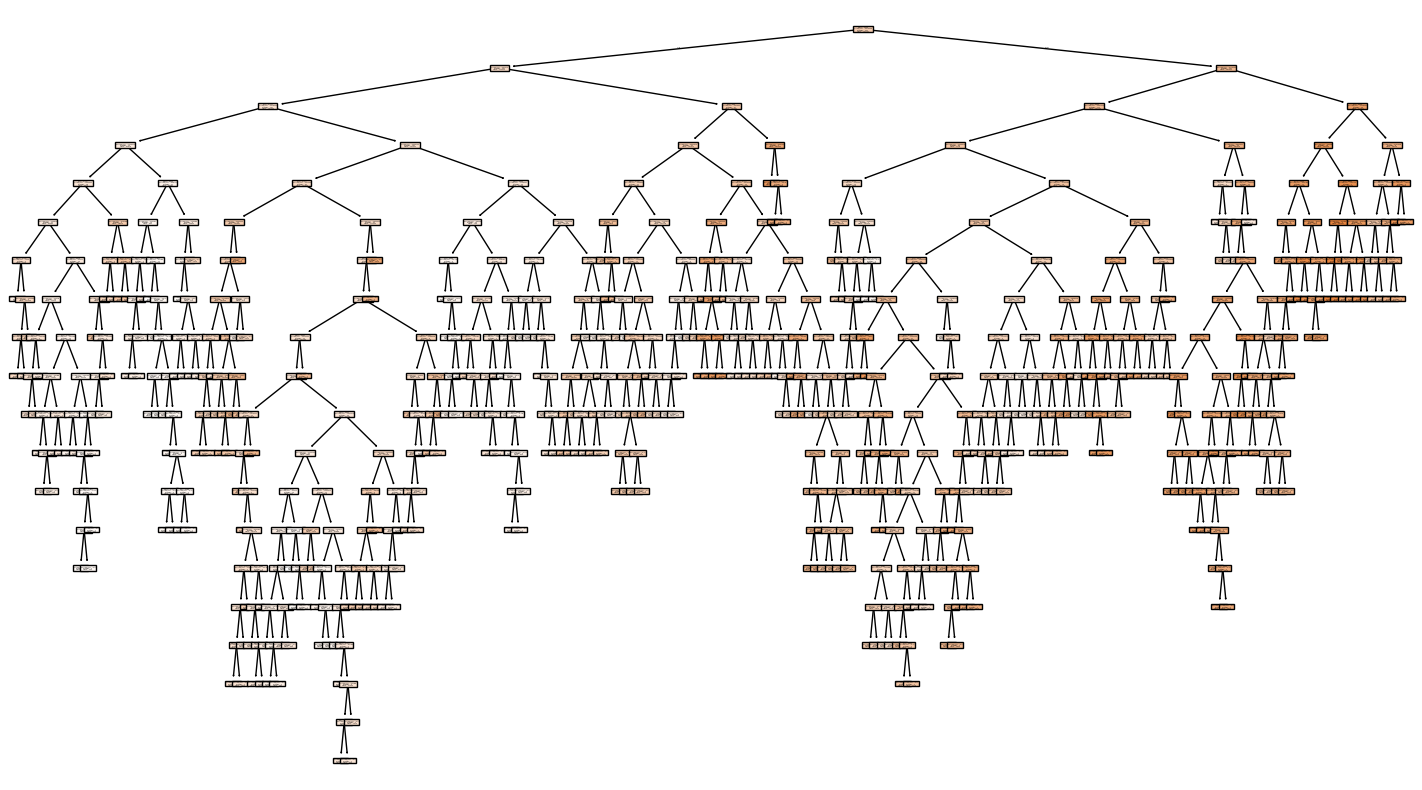

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled = True
)